# Customer Personality Analysis: Exploratory Data Analysis (EDA)
This notebook provides a structured EDA of the marketing dataset to uncover business insights and customer behavior patterns.

## 1. Basic Data Inspection

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# Load dataset
df = pd.read_excel('marketing_campaign.xlsx')

In [6]:
# Shape, info, describe
display(df.shape)
display(df.info())
display(df.describe(include='all'))

(2240, 29)

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[us]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

None

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,NaN,NaN,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
# Check missing values and duplicates
display(df.isnull().sum())
display(df.duplicated().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

np.int64(0)

## 2. Data Cleaning

In [8]:
# Drop unnecessary columns
df = df.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis=1)

In [9]:
# Convert Year_Birth to Age
df['Age'] = 2026 - df['Year_Birth']
df = df.drop('Year_Birth', axis=1)

In [10]:
# Convert Dt_Customer to datetime and create Customer_Since_Years
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Customer_Since_Years'] = 2026 - df['Dt_Customer'].dt.year

In [11]:
# Ensure proper data types
cat_cols = ['Education', 'Marital_Status', 'Response', 'Complain']
for col in cat_cols:
    df[col] = df[col].astype('category')

## 3. Feature Engineering

In [12]:
# Create Total_Spending and Total_Purchases
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Spending'] = df[mnt_cols].sum(axis=1)
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

In [13]:
# Create Children_Count
df['Children_Count'] = df['Kidhome'] + df['Teenhome']

## 4. Univariate Analysis

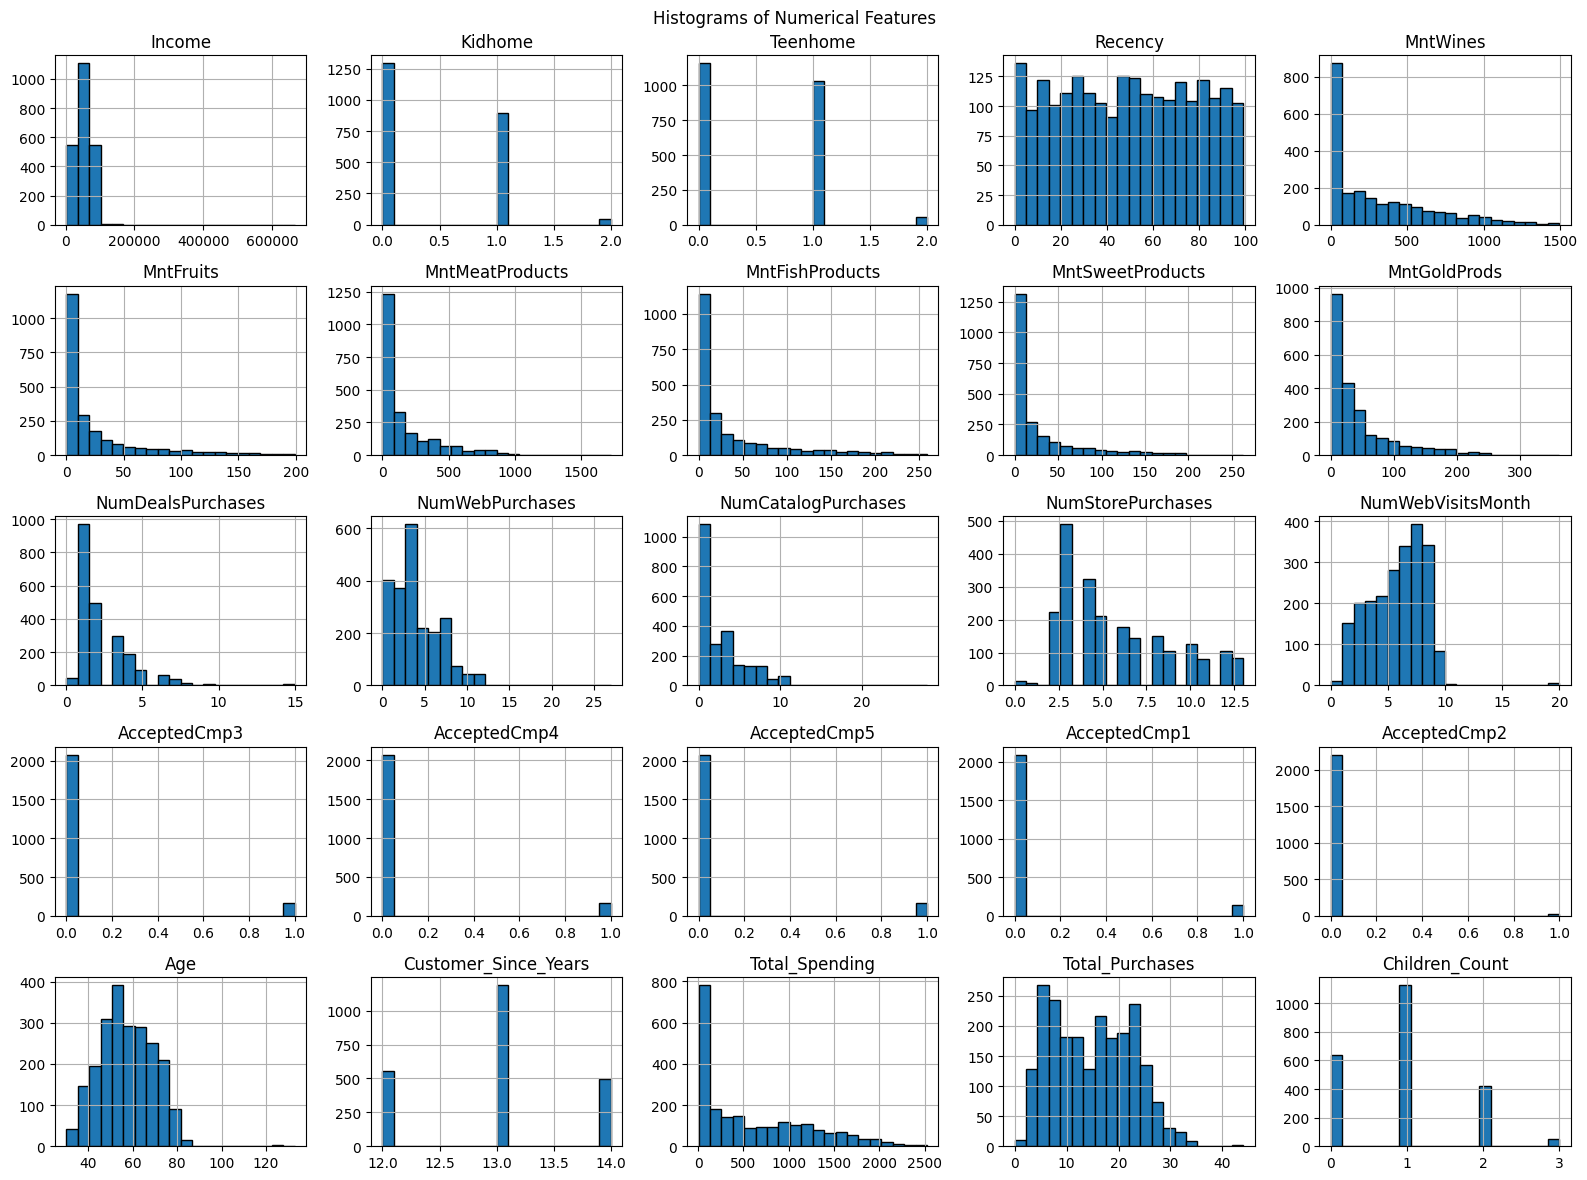

In [14]:
# Histograms for numerical features
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

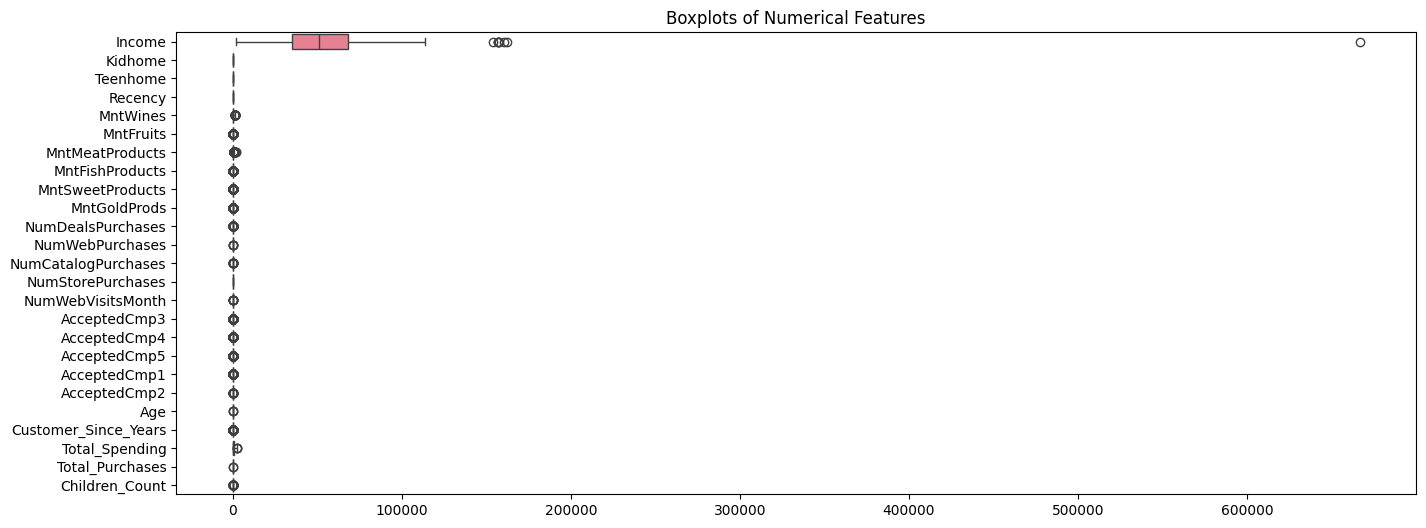

In [15]:
# Boxplots for outlier detection
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title('Boxplots of Numerical Features')
plt.show()

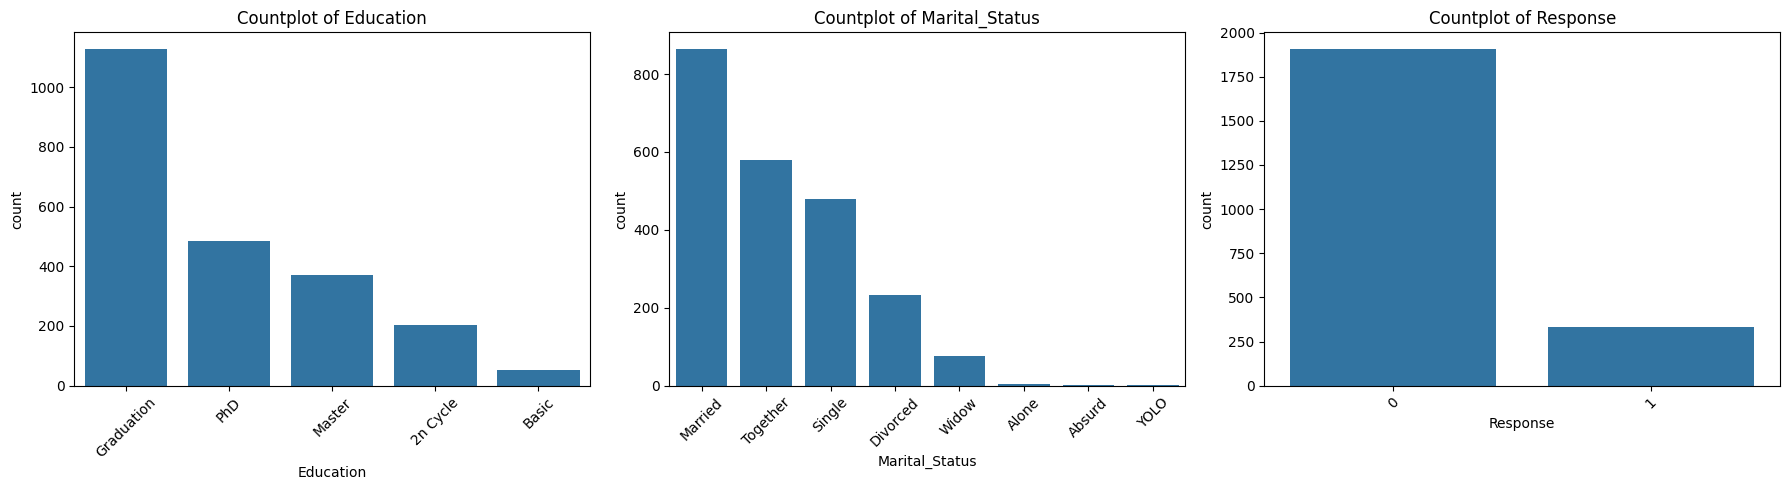

In [16]:
# Countplots for categorical features
cat_features = ['Education', 'Marital_Status', 'Response']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.countplot(x=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Countplot of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

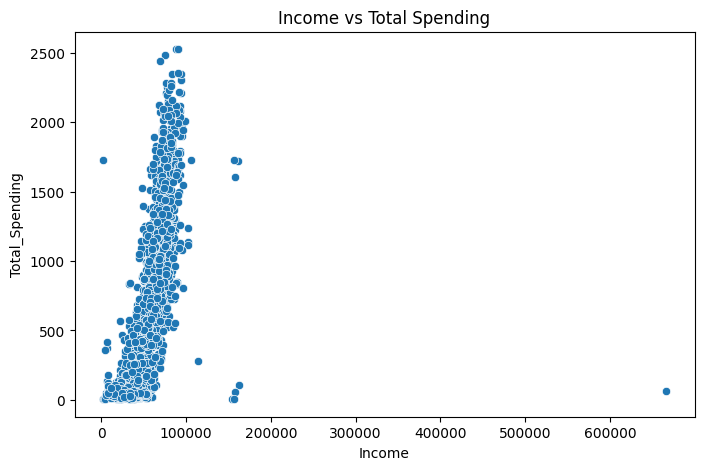

In [17]:
# Income vs Total_Spending
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title('Income vs Total Spending')
plt.show()

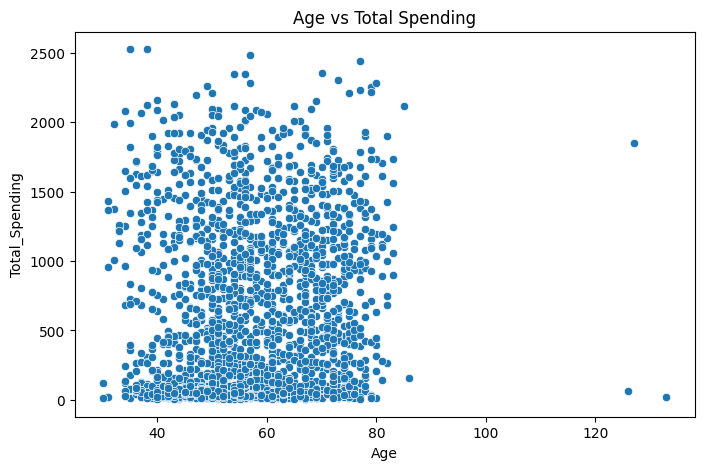

In [18]:
# Age vs Total_Spending
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.title('Age vs Total Spending')
plt.show()

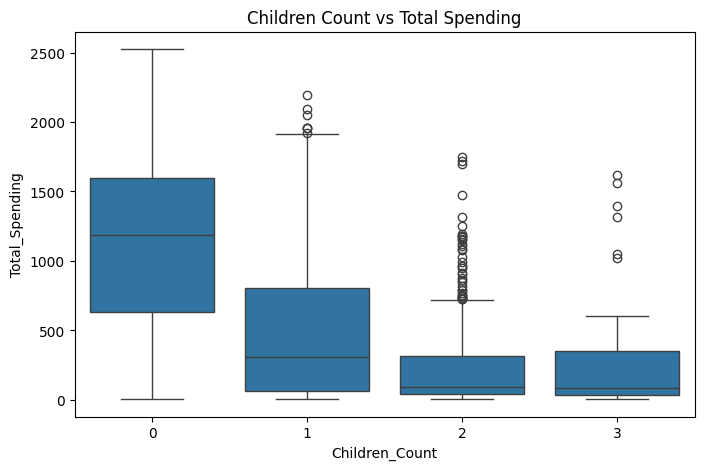

In [19]:
# Children_Count vs Total_Spending
plt.figure(figsize=(8, 5))
sns.boxplot(x='Children_Count', y='Total_Spending', data=df)
plt.title('Children Count vs Total Spending')
plt.show()

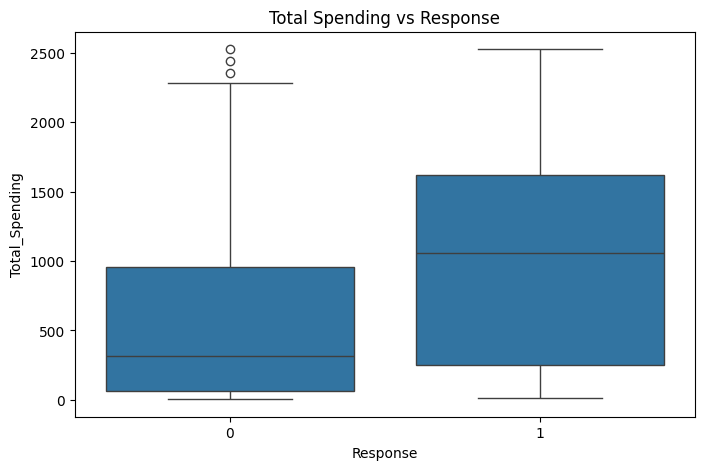

In [20]:
# Total_Spending vs Response
plt.figure(figsize=(8, 5))
sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.title('Total Spending vs Response')
plt.show()

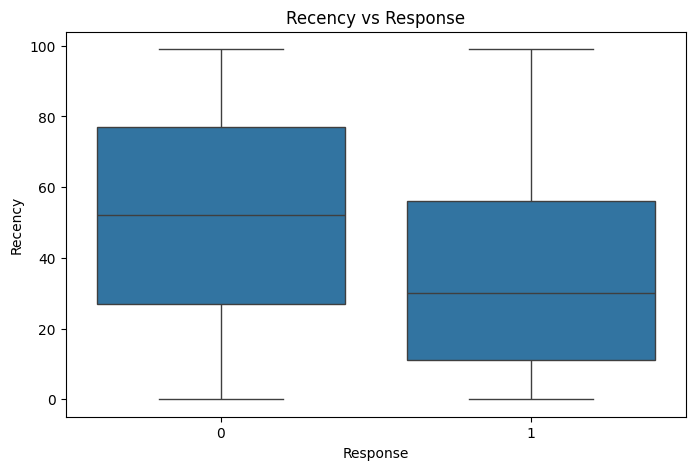

In [21]:
# Recency vs Response
plt.figure(figsize=(8, 5))
sns.boxplot(x='Response', y='Recency', data=df)
plt.title('Recency vs Response')
plt.show()

## 6. Correlation Analysis

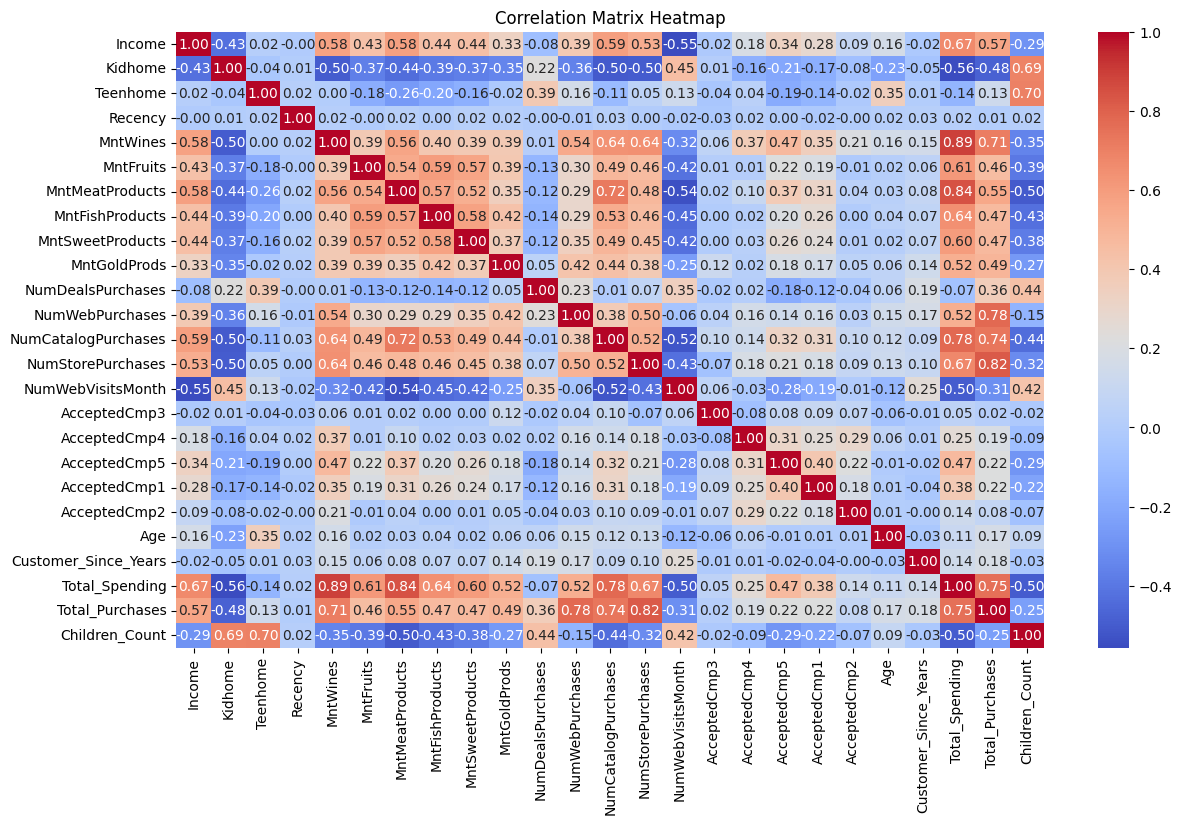

In [22]:
# Correlation matrix and heatmap
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(14, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

## 7. Campaign Analysis

In [23]:
# Acceptance rate of each campaign
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
acceptance_rates = df[cmp_cols].mean().sort_values(ascending=False)
display(acceptance_rates)

AcceptedCmp4    0.074554
AcceptedCmp5    0.072768
AcceptedCmp3    0.072768
AcceptedCmp1    0.064286
AcceptedCmp2    0.013393
dtype: float64

In [24]:
# Compare responders vs non-responders
responders = df[df['Response'] == 1]
non_responders = df[df['Response'] == 0]
display(responders.describe())
display(non_responders.describe())

,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,Customer_Since_Years,Total_Spending,Total_Purchases,Children_Count
count,333.000000,334.000000,334.000000,334,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,...,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000
mean,60209.675676,0.341317,0.305389,2013-04-07 12:51:44.191616,35.383234,502.703593,38.203593,294.353293,52.050898,38.634731,...,0.230539,0.185629,0.275449,0.236527,0.059880,56.583832,13.251497,987.392216,17.706587,0.646707
min,7500.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,12.000000,17.000000,4.000000,0.000000
25%,39763.000000,0.000000,0.000000,2012-10-16 12:00:00,11.000000,96.000000,4.000000,47.750000,4.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,13.000000,252.000000,12.000000,0.000000
50%,64090.000000,0.000000,0.000000,2013-02-23 12:00:00,30.000000,448.000000,21.000000,174.500000,25.000000,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,13.000000,1057.500000,18.500000,0.000000
75%,80589.000000,1.000000,1.000000,2013-08-20 18:00:00,56.000000,875.500000,53.750000,509.750000,84.250000,57.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,67.000000,14.000000,1617.000000,22.000000,1.000000
max,105471.000000,2.000000,2.000000,2014-06-23 00:00:00,99.000000,1492.000000,193.000000,981.000000,250.000000,198.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,83.000000,14.000000,2525.000000,34.000000,3.000000
std,23194.080987,0.487347,0.492741,NaN,27.659499,427.183786,46.099519,286.890036,61.855885,46.327903,...,0.421810,0.389390,0.447411,0.425587,0.237621,12.398192,0.690724,719.009695,6.856584,0.739920


,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,Customer_Since_Years,Total_Spending,Total_Purchases,Children_Count
count,1883.000000,1906.000000,1906.000000,1906,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,...,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000
mean,50839.132767,0.462225,0.541448,2013-07-26 20:51:52.696747,51.514690,269.104407,24.216684,144.624344,34.980063,25.035152,...,0.045121,0.055089,0.037251,0.034103,0.005247,57.301154,12.922875,538.929171,14.363589,1.003673
min,1730.000000,0.000000,0.000000,2012-07-31 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,12.000000,5.000000,0.000000,0.000000
25%,34421.000000,0.000000,0.000000,2013-02-13 00:00:00,27.000000,21.250000,1.000000,14.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,49.000000,12.000000,62.000000,7.000000,1.000000
50%,50150.000000,0.000000,1.000000,2013-08-02 00:00:00,52.000000,152.000000,7.000000,56.000000,11.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,13.000000,314.000000,14.000000,1.000000
75%,66308.000000,1.000000,1.000000,2014-01-16 12:00:00,77.000000,443.750000,28.000000,192.750000,43.000000,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,13.000000,956.000000,21.000000,1.000000
max,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,133.000000,14.000000,2525.000000,44.000000,3.000000
std,25252.804747,0.544975,0.545670,NaN,28.519092,305.159188,38.191763,205.299936,52.870253,40.001067,...,0.207623,0.228214,0.189425,0.181541,0.072262,11.910143,0.671764,553.103565,7.706323,0.741345


In [25]:
# Insights about campaign effectiveness
print('Campaign acceptance rates:')
print(acceptance_rates)
print('\nResponders vs Non-Responders:')
print('Responders:', len(responders), 'Non-Responders:', len(non_responders))

Campaign acceptance rates:
AcceptedCmp4    0.074554
AcceptedCmp5    0.072768
AcceptedCmp3    0.072768
AcceptedCmp1    0.064286
AcceptedCmp2    0.013393
dtype: float64

Responders vs Non-Responders:
Responders: 334 Non-Responders: 1906


### Summary
This EDA provides a comprehensive overview of the customer data, highlights key behavioral patterns, and sets the stage for deeper customer segmentation and predictive modeling.